<a href="https://colab.research.google.com/github/vishnu123434/AIML_PROJECTS/blob/main/Multiple_Regression_PROJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.kaggle.com/datasets/debajyotipodder/co2-emission-by-vehicles

# IML_Lab5a_Multiple Regression_co2

# **AIM**------------------
## 3. Build a multiple regression model using python on given data set by
####a.   Prepare the data for ML model
####b.   Splitting Training data and Test data.
####c.   FIT & Evaluate the model (intercept and slope).
####d.   predicting the test set result
####e.  Visualize the training set and testing set using  Matplotlib, Seaborne.
####f.   compare actual output values with predicted values
####g.   Calculate MSE,MAE,RMSE without & with outliers detection and removal





In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
# Import Dataset from the Drive
df=pd.read_csv('/content/drive/MyDrive/datasets/CO2 Emissions_Canada.csv')


In [ ]:
# shape of the Dataset
df.shape

(7385, 12)

# a. Prepare the data for ML model

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [ ]:
# rename the selected attributes
df.rename(columns={'CO2 Emissions(g/km)' : 'CO2_emission'}, inplace=True)
df.rename(columns={'Engine Size(L)' : 'Enginesize'}, inplace=True)
df.rename(columns={'Fuel Consumption City (L/100 km)' : 'fuelconsumptioncity'}, inplace=True)
df.rename(columns={'Fuel Consumption Hwy (L/100 km)' : 'fuelconsumptionhwy'}, inplace=True)
df.rename(columns={'Fuel Consumption Comb (L/100 km)' : 'fuelconsumptioncomb'}, inplace=True)
df.rename(columns={'Fuel Consumption Comb (mpg)' : 'fuelconsumptioncombmpg'}, inplace=True)


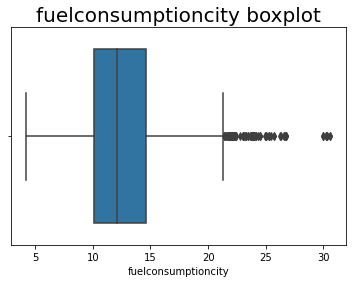

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=df.fuelconsumptioncity)
plt.title('fuelconsumptioncity boxplot', fontsize = 20)
plt.show()

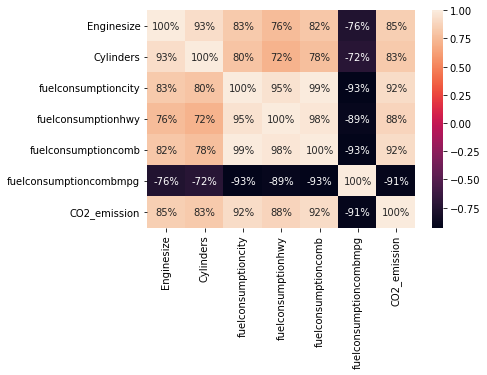

In [ ]:
sns.heatmap(df.corr(),annot=True, fmt='.0%')


#b. Splitting  Input X and Target Y into Training data and Test data.

In [ ]:
X=df[['Enginesize','fuelconsumptioncity','fuelconsumptionhwy','fuelconsumptioncomb','fuelconsumptioncombmpg']]
Y=df[["CO2_emission"]]

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=42,shuffle=True)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(5169, 5)
(2216, 5)
(5169, 1)
(2216, 1)


# c. FIT & Evaluate the model (intercept and slope).

In [ ]:
from sklearn.linear_model import LinearRegression
lm=LinearRegression().fit(X_train,Y_train)
print("Linear Regression Model  is Fitted between X_train and Y_train")

Linear Regression Model  is Fitted between X_train and Y_train


In [ ]:
print(lm.coef_)
print(lm.intercept_)

[[13.13600953  3.07339773  3.91210199 -0.45411835 -3.20929138]]
[228.41107668]


# D. predicting the test set result

In [ ]:
Y_test_pred=lm.predict(X_test)

In [ ]:
#result_ditribution=Y_test-Y_test_pred
#sns.distplot(result_ditribution)

# g. Calculate MSE,MAE,RMSE

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
mse=mean_squared_error(Y_test,Y_test_pred)
print("MSE=",mse)
mae=mean_absolute_error(Y_test,Y_test_pred)
print("MAE=",mae)
rmse=np.sqrt(mse)
print("RMSE=",rmse)

MSE= 354.4218680258516
MAE= 11.567954709691929
RMSE= 18.826095400423625


In [ ]:
from sklearn.metrics import r2_score
r2=r2_score(Y_test,Y_test_pred)
print(r2)

0.8950702291570182


#H. New Data prediction


In [ ]:
new_pred=lm.predict([[3.2,5.3,8.3,7.1,34]])[0]
print("CO2 Emission for new data :",new_pred)
print("\n")

CO2 Emission for new data : [206.8656146]




/usr/local/lib/python3.8/dist-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


#  --------------------**END**-----------------------

https://www.analyticsvidhya.com/blog/2021/04/gradient-descent-in-linear-regression/#:~:text=Gradient%20Descent%20Algorithm,-Gradient%20Descent%20is&text=The%20algorithm%20starts%20with%20some,some%20amount%20(Learning%20Step).

https://analyticsindiamag.com/outlier-detection-using-z-score-a-complete-guide-with-python-codes/

  Dont write this

In [ ]:
#df.columns = df.columns.str.replace(' ', '')
#df.columns
#cols = df.columns.str.strip().str.lower().str.replace(' ','_').str.replace('(','').str.replace(')','')
#cols

In [ ]:
#df.columns = df.columns.str.replace(' ', '')
#df.columns
#cols = df.columns.str.strip().str.lower().str.replace(' ','_').str.replace('(','').str.replace(')','')
#cols